# Clase 1 - XOR con 3 neuronas (desde cero)

Resolvemos la compuerta **XOR** con una red feed-forward de 2 capas, implementada solo con NumPy (sin PyTorch).

**Arquitectura** (slide 21 de la clase):

- Entrada: $X_1, X_2$
- Layer 1 (oculta): 2 neuronas, activación **sigmoid** $\rightarrow a_1, a_2$
- Layer 2 (salida): 1 neurona, **sin** activación $\rightarrow \hat{y}$
- Total: **3 neuronas** (2 + 1), **9 parámetros** entrenables.

**Loss:** Error cuadrático $L = (y - \hat{y})^2$

Por qué no alcanza un modelo lineal: XOR no es linealmente separable, una recta no separa las clases. Necesitamos la no-linealidad de la sigmoid en la capa oculta.

## Forward pass

$$Z^{(1)}_{i,1} = W^{(1)}_{1,1}\,X_{i,1} + W^{(1)}_{1,2}\,X_{i,2} + b^{(1)}_1$$
$$Z^{(1)}_{i,2} = W^{(1)}_{2,1}\,X_{i,1} + W^{(1)}_{2,2}\,X_{i,2} + b^{(1)}_2$$
$$a^{(1)}_{i,1} = \sigma(Z^{(1)}_{i,1}), \quad a^{(1)}_{i,2} = \sigma(Z^{(1)}_{i,2})$$
$$Z^{(2)}_{i,1} = W^{(2)}_{1,1}\,a^{(1)}_{i,1} + W^{(2)}_{1,2}\,a^{(1)}_{i,2} + b^{(2)}_1$$
$$\hat{y}_i = a^{(2)}_{i,1} = Z^{(2)}_{i,1}$$
$$L = (y_i - \hat{y}_i)^2$$

In [54]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

def sigmoid(z):
    return 1.0 / (1.0 + np.exp(-z))

# Dataset XOR
X = np.array([[0, 0],
              [0, 1],
              [1, 0],
              [1, 1]], dtype=float)
y = np.array([0, 1, 1, 0], dtype=float)

print(X)
print(y)

[[0. 0.]
 [0. 1.]
 [1. 0.]
 [1. 1.]]
[0. 1. 1. 0.]


## Las 9 derivadas parciales (backpropagation a mano)

Aplicamos regla de la cadena partiendo de $L = (y-\hat{y})^2$.

Cantidades intermedias:
$$\frac{\partial L}{\partial \hat{y}} = -2(y-\hat{y}), \qquad \frac{\partial \hat{y}}{\partial Z^{(2)}} = 1$$
$$\sigma'(z) = \sigma(z)\,(1-\sigma(z)) \;\Rightarrow\; \frac{\partial a^{(1)}_1}{\partial Z^{(1)}_1} = a_1(1-a_1), \quad \frac{\partial a^{(1)}_2}{\partial Z^{(1)}_2} = a_2(1-a_2)$$

Definimos $\delta = \dfrac{\partial L}{\partial Z^{(2)}} = -2(y-\hat{y})$.

**Capa 2 (3 derivadas):**
$$\frac{\partial L}{\partial W^{(2)}_{1,1}} = \delta\, a_1 \qquad \frac{\partial L}{\partial W^{(2)}_{1,2}} = \delta\, a_2 \qquad \frac{\partial L}{\partial b^{(2)}_1} = \delta$$

Propagamos a la capa oculta:
$$\delta_1 = \frac{\partial L}{\partial Z^{(1)}_1} = \delta\,W^{(2)}_{1,1}\,a_1(1-a_1) \qquad \delta_2 = \frac{\partial L}{\partial Z^{(1)}_2} = \delta\,W^{(2)}_{1,2}\,a_2(1-a_2)$$

**Capa 1 (6 derivadas):**
$$\frac{\partial L}{\partial W^{(1)}_{1,1}} = \delta_1\,X_1 \qquad \frac{\partial L}{\partial W^{(1)}_{1,2}} = \delta_1\,X_2 \qquad \frac{\partial L}{\partial b^{(1)}_1} = \delta_1$$
$$\frac{\partial L}{\partial W^{(1)}_{2,1}} = \delta_2\,X_1 \qquad \frac{\partial L}{\partial W^{(1)}_{2,2}} = \delta_2\,X_2 \qquad \frac{\partial L}{\partial b^{(1)}_2} = \delta_2$$

Total: **3 + 6 = 9 derivadas**, una por parámetro.

In [55]:
# Inicializacion de los 9 parametros
# W1: matriz 2x2 (fila = neurona, columna = entrada)
W1 = np.random.randn(2, 2)
b1 = np.random.randn(2)
# W2: 2 pesos (uno por neurona oculta), b2: escalar
W2 = np.random.randn(2)
b2 = np.random.randn()

def forward(x):
    """x = [x1, x2]. Devuelve y_hat y cache para backprop."""
    x1, x2 = x
    z1_1 = W1[0, 0] * x1 + W1[0, 1] * x2 + b1[0]
    z1_2 = W1[1, 0] * x1 + W1[1, 1] * x2 + b1[1]
    a1 = sigmoid(z1_1)
    a2 = sigmoid(z1_2)
    z2 = W2[0] * a1 + W2[1] * a2 + b2
    y_hat = z2  # sin activacion en la salida
    cache = (x1, x2, a1, a2)
    return y_hat, cache

def gradientes(y_true, y_hat, cache):
    """Devuelve las 9 derivadas parciales."""
    x1, x2, a1, a2 = cache
    delta = -2.0 * (y_true - y_hat)            # dL/dZ2

    # ---- Capa 2 (3 derivadas) ----
    dW2_11 = delta * a1
    dW2_12 = delta * a2
    db2    = delta

    # ---- Propagacion a capa oculta ----
    delta1 = delta * W2[0] * a1 * (1.0 - a1)   # dL/dZ1_1
    delta2 = delta * W2[1] * a2 * (1.0 - a2)   # dL/dZ1_2

    # ---- Capa 1 (6 derivadas) ----
    dW1_11 = delta1 * x1
    dW1_12 = delta1 * x2
    db1_1  = delta1
    dW1_21 = delta2 * x1
    dW1_22 = delta2 * x2
    db1_2  = delta2

    gW1 = np.array([[dW1_11, dW1_12],
                    [dW1_21, dW1_22]])
    gb1 = np.array([db1_1, db1_2])
    gW2 = np.array([dW2_11, dW2_12])
    gb2 = db2
    return gW1, gb1, gW2, gb2

## SGD (Stochastic Gradient Descent)

Regla de actualizacion: $\vec{W} \leftarrow \vec{W} - \alpha\,\nabla_{\vec{W}} L$.

SGD = actualizamos los parametros muestra por muestra (no en batch). En cada epoch barajamos las 4 muestras.

In [56]:
alpha = 0.2        # learning rate
epochs = 1000
mse_history = []

for epoch in range(epochs):
    idx = np.random.permutation(len(X))   # barajar -> estocastico
    for i in idx:
        y_hat, cache = forward(X[i])
        gW1, gb1, gW2, gb2 = gradientes(y[i], y_hat, cache)
        # actualizar los 9 parametros
        W1 -= alpha * gW1
        b1 -= alpha * gb1
        W2 -= alpha * gW2
        b2 -= alpha * gb2

    # MSE sobre todo el dataset al final del epoch
    preds = np.array([forward(x)[0] for x in X])
    mse = np.mean((y - preds) ** 2)
    # print(f"Epoch {epoch+1}/{epochs}, MSE: {mse:.6f}")
    mse_history.append(mse)

print(f"MSE inicial: {mse_history[0]:.5f}")
print(f"MSE final:   {mse_history[-1]:.6f}")

MSE inicial: 0.60441
MSE final:   0.000000


## Grafico MSE por epoch

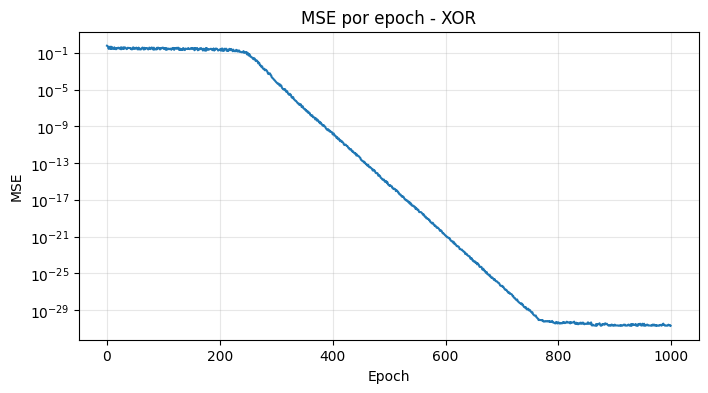

In [57]:
plt.figure(figsize=(8, 4))
plt.plot(mse_history)
plt.xlabel("Epoch")
plt.ylabel("MSE")
plt.title("MSE por epoch - XOR")
plt.yscale("log")
plt.grid(True, alpha=0.3)
plt.show()

## Predicciones - verificacion

La salida no tiene activacion, asi que $\hat{y}$ es un valor continuo. Redondeamos para obtener la clase y comparamos con la tabla XOR esperada $[0, 1, 1, 0]$.

In [58]:
print(f"{'X1':>3} {'X2':>3} | {'y_real':>7} {'y_hat':>9} {'pred':>5}")
print("-" * 34)
for i in range(len(X)):
    y_hat, _ = forward(X[i])
    pred = int(round(y_hat))
    print(f"{int(X[i,0]):>3} {int(X[i,1]):>3} | {int(y[i]):>7} {y_hat:>9.4f} {pred:>5}")

 X1  X2 |  y_real     y_hat  pred
----------------------------------
  0   0 |       0    0.0000     0
  0   1 |       1    1.0000     1
  1   0 |       1    1.0000     1
  1   1 |       0   -0.0000     0
